# What if toast could predict the weather?

Notebook de la columna del blog [Prancing Pony](https://sierraporta.github.io/prancing-pony/): simulamos un año de tostadas y temperaturas **completamente independientes entre sí**, y mostramos cómo aun así aparecen correlaciones "significativas", descubrimientos falsos por *data dredging*, y modelos que ajustan bien el pasado pero fracasan prediciendo el futuro.

**Estructura:**

1. Un año de tostadas y temperaturas (correlación espuria entre dos series independientes)
2. *Data dredging*: 1000 variables de cocina contra la misma temperatura
3. Sobreajuste: entrenar con 9 meses, probar con 3
4. Caminatas aleatorias independientes que parecen gemelas

Todas las simulaciones usan semillas fijas (`default_rng(seed)`), así que los resultados son exactamente reproducibles.

## Configuración

Importamos las librerías y fijamos el escenario: $n = 365$ días (un año de desayunos). Las figuras se guardan en `./Figures/`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
import os

FIGDIR = "./Figures"
os.makedirs(FIGDIR, exist_ok=True)
plt.rcParams.update({"font.size": 11, "figure.dpi": 150})

n = 365            # días del año
t = np.arange(n)   # eje temporal

## Los generadores de datos: cómo se simula todo

**Proceso AR(1) (autorregresivo de orden 1).** Es el bloque básico de todas las series de este notebook:

$$x_t = \phi\, x_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0, \sigma^2)$$

El parámetro $\phi \in [0,1)$ controla la **memoria** de la serie: con $\phi$ cercano a 0 la serie es casi ruido blanco (cada día olvida el anterior); con $\phi$ cercano a 1 la serie es muy persistente (el valor de hoy se parece mucho al de ayer y las excursiones lejos de cero duran semanas). Esa persistencia es la clave de todo el artículo: es lo que hace que dos series independientes puedan correlacionar fuerte por puro azar.

**Temperatura.** Se simula como un ciclo estacional sinusoidal más ruido AR(1) de memoria moderada:

$$T_t = 27 + 4\sin\!\left(\frac{2\pi (t - 100)}{365}\right) + u_t, \qquad u_t = \text{AR(1)}(\phi = 0.7,\ \sigma = 0.8)$$

Es decir: media anual de 27 °C, amplitud estacional de ±4 °C, y fluctuaciones diarias correlacionadas (un día caluroso tiende a seguir a otro caluroso). **Nota importante:** la temperatura no depende de ninguna otra variable del notebook.

In [2]:
def ar1(n, phi, sigma, rng):
    '''Simula un proceso AR(1): x[t] = phi*x[t-1] + ruido gaussiano N(0, sigma^2).

    phi   : memoria de la serie (0 = ruido blanco, cercano a 1 = muy persistente)
    sigma : desviación estándar de las innovaciones
    rng   : generador de números aleatorios (para reproducibilidad)
    '''
    x = np.zeros(n)
    for i in range(1, n):
        x[i] = phi * x[i-1] + rng.normal(0, sigma)
    return x

def make_temp(rng):
    '''Temperatura máxima diaria simulada: ciclo anual (27 ± 4 °C, pico cerca del día 190)
    + fluctuaciones AR(1) con memoria moderada (phi=0.7).'''
    seasonal = 27 + 4*np.sin(2*np.pi*(t-100)/365)
    return seasonal + ar1(n, 0.7, 0.8, rng)

## 1. Un año de tostadas y temperaturas

**Cómo se simula el índice de tostado.** Es un AR(1) *muy* persistente ($\phi = 0.98$, $\sigma = 0.35$), reescalado para vivir en la escala 0–100:

$$\text{tostado}_t = \mathrm{clip}\big(50 + 12\, z_t,\ 0,\ 100\big), \qquad z_t = \text{AR(1)}(\phi=0.98,\ \sigma=0.35)$$

La persistencia alta imita un tostador que se degrada lentamente: el nivel de tostado de hoy se parece al de ayer, y las derivas duran semanas. **El tostado no usa la temperatura en ninguna parte**: ambas series se generan de forma independiente.

**Sobre el bucle de semillas (confesión metodológica).** El código prueba semillas hasta encontrar una donde la correlación tostado–temperatura cae entre 0.48 y 0.60. Esto es, deliberadamente, una forma de *cherry-picking*: elegimos "el año" que cuenta bien la historia, igual que un investigador descuidado elegiría el dataset que confirma su hipótesis. No es trampa oculta sino el punto pedagógico: con series persistentes, años así aparecen con frecuencia (pruébelo: quite el filtro y mire la distribución de r sobre todas las semillas). El p-valor que reportamos ignora esa búsqueda — exactamente como ocurre en el *data dredging* real.

In [3]:
# Buscar una semilla cuyo "año" tenga correlación jugosa (0.48 <= r <= 0.60)
best = None
for seed in range(400):
    rng = np.random.default_rng(seed)
    temp = make_temp(rng)                                  # temperatura simulada
    toast = np.clip(50 + 12*ar1(n, 0.98, 0.35, rng), 0, 100)  # índice de tostado, independiente
    r, p = stats.pearsonr(toast, temp)
    if 0.48 <= r <= 0.60:
        best = (seed, r, p)
        break

seed, r1, p1 = best
rng = np.random.default_rng(seed)
temp = make_temp(rng)
toast = np.clip(50 + 12*ar1(n, 0.98, 0.35, rng), 0, 100)
print(f"semilla={seed}  r={r1:.3f}  p={p1:.2e}")

semilla=13  r=0.524  p=3.48e-27


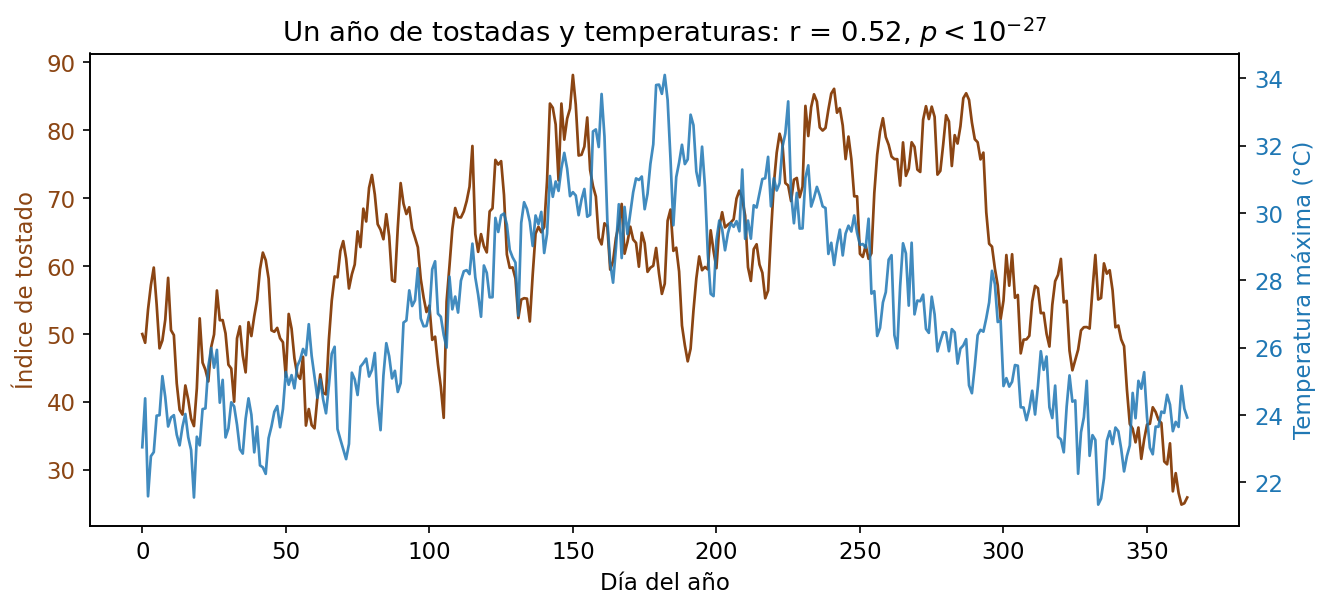

In [4]:
# Figura 1: las dos series superpuestas (ejes gemelos)
fig, ax1 = plt.subplots(figsize=(9, 4.2))
ax1.plot(t, toast, color="#8B4513", lw=1.3, label="Índice de tostado (0–100)")
ax1.set_xlabel("Día del año")
ax1.set_ylabel("Índice de tostado", color="#8B4513")
ax1.tick_params(axis="y", labelcolor="#8B4513")
ax2 = ax1.twinx()
ax2.plot(t, temp, color="#1f77b4", lw=1.3, alpha=0.85, label="Temperatura máxima (°C)")
ax2.set_ylabel("Temperatura máxima (°C)", color="#1f77b4")
ax2.tick_params(axis="y", labelcolor="#1f77b4")
ax1.set_title(f"Un año de tostadas y temperaturas: r = {r1:.2f}, $p < 10^{{{int(np.floor(np.log10(p1)))}}}$")
fig.tight_layout()
fig.savefig(f"{FIGDIR}/ToastTemp.png", bbox_inches="tight")
plt.show()

## 2. *Data dredging*: 1000 variables de cocina

**Qué se simula.** Generamos 1000 series AR(1) independientes muy persistentes ($\phi = 0.97$, $\sigma = 1$) — las "variables de cocina": tiempo de la cafetera, migas en el plato, etc. Ninguna tiene relación con la temperatura. A cada una le calculamos su correlación de Pearson (y su p-valor) contra **la misma** serie de temperatura.

**Qué esperar.** Si los tests funcionaran como promete el nivel $\alpha = 0.05$, alrededor del 5% saldría "significativa" por azar. Veremos que el porcentaje real es enormemente mayor, por dos razones combinadas: (a) la persistencia de las series infla las correlaciones muestrales, y (b) al hacer 1000 pruebas, quedarnos con las mejores es garantía de encontrar "descubrimientos". La corrección honesta para comparaciones múltiples (Bonferroni) exigiría $p < 0.05/1000$.

In [5]:
rng2 = np.random.default_rng(42)
temp2 = make_temp(rng2)

# 1000 variables de cocina: AR(1) persistentes, independientes de la temperatura
rs, ps = [], []
for _ in range(1000):
    x = ar1(n, 0.97, 1.0, rng2)
    r, p = stats.pearsonr(x, temp2)
    rs.append(r); ps.append(p)
rs, ps = np.array(rs), np.array(ps)

sig = np.mean(ps < 0.05) * 100     # % "significativas" al 5%
big = np.mean(np.abs(rs) > 0.3) * 100
imax = np.argmax(np.abs(rs))       # la variable "ganadora"
print(f"significativas (p<0.05): {sig:.1f}%  |  |r|>0.3: {big:.1f}%")
print(f"mejor variable: r={rs[imax]:.3f}, p={ps[imax]:.1e}")

significativas (p<0.05): 76.9%  |  |r|>0.3: 39.9%
mejor variable: r=-0.800, p=1.1e-82


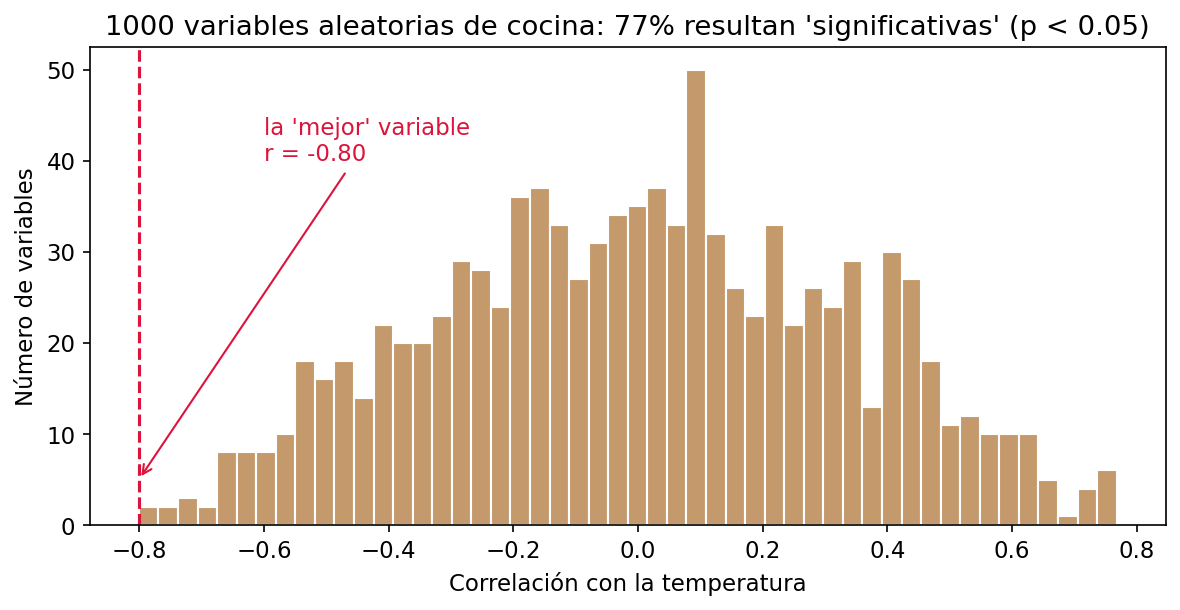

In [6]:
# Figura 2: histograma de las 1000 correlaciones, con la "ganadora" señalada
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(rs, bins=50, color="#c49a6c", edgecolor="white")
ax.axvline(rs[imax], color="crimson", ls="--", lw=1.5)
ax.annotate(f"la 'mejor' variable\nr = {rs[imax]:.2f}", xy=(rs[imax], 5),
            xytext=(rs[imax]-0.55 if rs[imax] > 0 else rs[imax]+0.2, 40),
            arrowprops=dict(arrowstyle="->", color="crimson"), color="crimson")
ax.set_xlabel("Correlación con la temperatura")
ax.set_ylabel("Número de variables")
ax.set_title(f"1000 variables aleatorias de cocina: {sig:.0f}% resultan 'significativas' (p < 0.05)")
fig.tight_layout()
fig.savefig(f"{FIGDIR}/DredgingHist.png", bbox_inches="tight")
plt.show()

## 3. Sobreajuste: entrenar con el pasado, fallar con el futuro

**Qué modelos se usan.** Regresión polinomial de grado $d = 1, \dots, 12$: para cada grado construimos un *pipeline* de scikit-learn que primero expande el índice de tostado en potencias ($x, x^2, \dots, x^d$, con `PolynomialFeatures`) y luego ajusta una regresión lineal ordinaria (mínimos cuadrados, con `LinearRegression`). El grado $d$ funciona como perilla de **complejidad**: $d=1$ es una recta; $d=12$ puede retorcerse mucho.

**Cómo se evalúa.** División temporal honesta, sin barajar: se entrena con los primeros 274 días (enero–septiembre) y se evalúa en los últimos 91 (octubre–diciembre). La métrica es
$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2},$$
que compara el modelo contra el predictor más tonto posible (la media). Un $R^2$ **negativo** en prueba significa que el modelo predice *peor* que usar simplemente el promedio histórico — la firma del sobreajuste a una relación que nunca existió.

In [7]:
# División temporal: 9 meses de entrenamiento, 3 de prueba (sin barajar: es una serie temporal)
split = 274
Xtr, Xte = toast[:split].reshape(-1, 1), toast[split:].reshape(-1, 1)
ytr, yte = temp[:split], temp[split:]

# Para cada grado d: pipeline = expansión polinomial + regresión por mínimos cuadrados
degs = range(1, 13)
r2tr, r2te = [], []
for d in degs:
    m = make_pipeline(PolynomialFeatures(d), LinearRegression())
    m.fit(Xtr, ytr)
    r2tr.append(r2_score(ytr, m.predict(Xtr)))   # ajuste sobre lo ya visto
    r2te.append(r2_score(yte, m.predict(Xte)))   # predicción sobre lo nunca visto

print(f"R2 train: d=1 -> {r2tr[0]:.3f},  d=12 -> {r2tr[-1]:.3f}")
print(f"R2 test : d=1 -> {r2te[0]:.3f},  peor = {min(r2te):.3f} (grado {list(degs)[int(np.argmin(r2te))]})")

R2 train: d=1 -> 0.266,  d=12 -> 0.291
R2 test : d=1 -> -2.801,  peor = -5.044 (grado 5)


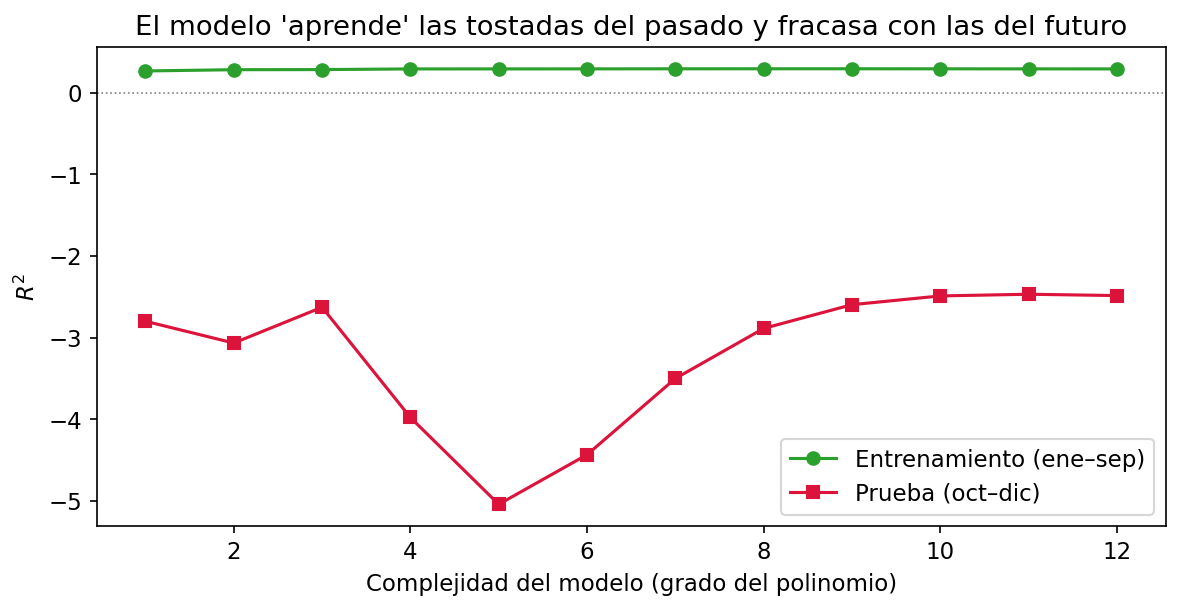

In [8]:
# Figura 3: R2 de entrenamiento vs prueba según la complejidad del modelo
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(list(degs), r2tr, "o-", color="#2ca02c", label="Entrenamiento (ene–sep)")
ax.plot(list(degs), r2te, "s-", color="crimson", label="Prueba (oct–dic)")
ax.axhline(0, color="gray", lw=0.8, ls=":")
ax.set_xlabel("Complejidad del modelo (grado del polinomio)")
ax.set_ylabel("$R^2$")
ax.set_title("El modelo 'aprende' las tostadas del pasado y fracasa con las del futuro")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIGDIR}/Overfit.png", bbox_inches="tight")
plt.show()

## 4. Caminatas aleatorias que parecen gemelas

**Qué se simula.** La caminata aleatoria es el caso extremo de persistencia ($\phi = 1$): puro azar acumulado,

$$x_t = x_{t-1} + \varepsilon_t = \sum_{s \le t} \varepsilon_s, \qquad \varepsilon_s \sim \mathcal{N}(0,1)$$

(en código: `np.cumsum(rng.normal(size=n))`). Generamos 2000 **pares independientes** de caminatas de 365 pasos y calculamos la correlación dentro de cada par.

**Qué esperar.** Para series independientes *sin* memoria, $|r|$ se concentraría cerca de 0 (típicamente $\sim 1/\sqrt{n} \approx 0.05$). Para caminatas aleatorias, en cambio, la distribución de $|r|$ es casi plana: la mediana ronda 0.4 y valores por encima de 0.9 no son raros. Es el fenómeno de las *nonsense correlations* que Yule describió en 1926. La celda también busca, entre unas cuantas semillas, un par especialmente correlacionado para ilustrarlo — de nuevo cherry-picking deliberado y declarado.

In [9]:
# 2000 pares de caminatas aleatorias independientes -> distribución de |r|
rng3 = np.random.default_rng(7)
rws = []
for _ in range(2000):
    a = np.cumsum(rng3.normal(size=n))   # caminata A: azar puro acumulado
    b = np.cumsum(rng3.normal(size=n))   # caminata B: independiente de A
    rws.append(stats.pearsonr(a, b)[0])
rws = np.array(rws)

med = np.median(np.abs(rws))
frac05 = np.mean(np.abs(rws) > 0.5) * 100
print(f"mediana |r| entre caminatas independientes: {med:.2f}  |  % con |r|>0.5: {frac05:.1f}%")

# Buscar un par ilustrativo con |r| alto (cherry-picking declarado)
rex, aex, bex = 0, None, None
for s in range(300):
    rg = np.random.default_rng(s)
    a = np.cumsum(rg.normal(size=n)); b = np.cumsum(rg.normal(size=n))
    rr = stats.pearsonr(a, b)[0]
    if abs(rr) > abs(rex):
        rex, aex, bex = rr, a, b
    if abs(rex) > 0.85:
        break
print(f"par de ejemplo: r = {rex:.2f}")

mediana |r| entre caminatas independientes: 0.43  |  % con |r|>0.5: 42.4%
par de ejemplo: r = 0.90


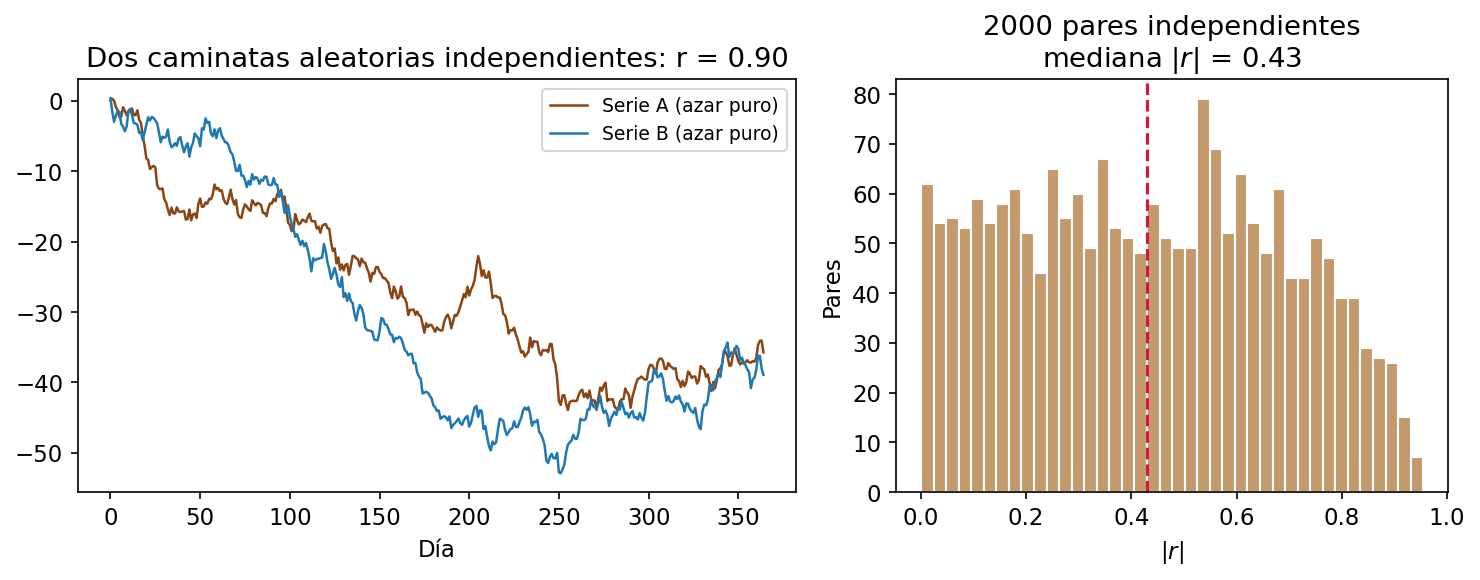

In [10]:
# Figura 4: un par "gemelo" (izquierda) y la distribución de |r| de los 2000 pares (derecha)
fig, (axl, axr) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={"width_ratios": [1.3, 1]})
axl.plot(aex, color="#8B4513", lw=1.2, label="Serie A (azar puro)")
axl.plot(bex if rex > 0 else -bex, color="#1f77b4", lw=1.2, label="Serie B (azar puro)")
axl.set_title(f"Dos caminatas aleatorias independientes: r = {abs(rex):.2f}")
axl.set_xlabel("Día"); axl.legend(fontsize=9)
axr.hist(np.abs(rws), bins=40, color="#c49a6c", edgecolor="white")
axr.axvline(med, color="crimson", ls="--", lw=1.5)
axr.set_title(f"2000 pares independientes\nmediana $|r|$ = {med:.2f}")
axr.set_xlabel("$|r|$"); axr.set_ylabel("Pares")
fig.tight_layout()
fig.savefig(f"{FIGDIR}/RandomWalks.png", bbox_inches="tight")
plt.show()

## Referencias

- Yule, G. U. (1926). *Why do we sometimes get nonsense-correlations between Time-Series? — A study in sampling and the nature of time-series*. Journal of the Royal Statistical Society, 89(1), 1–63. https://doi.org/10.2307/2341482
- Vigen, T. *Spurious Correlations*: https://www.tylervigen.com/spurious-correlations

**Moraleja del notebook:** una correlación fuerte y "significativa" no es evidencia de nada si las series tienen memoria y si no declaramos cuántas preguntas hicimos antes de quedarnos con la mejor respuesta. La prueba honesta siempre es predecir datos que el modelo nunca vio.